## Step-by-Step Guide to create figures to be shared with clients

**READ.ME**

This file guides 2-0 LCA consultants through the creation of streamlined figures with our brand identity. Requirement is the ability to calculate contribution analysis dataframes using Brightway after successfully importing your databases.

### 1. Set your background

In [2]:
# import libraries
import bw2data as bd
import bw2analyzer as bwa
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams

In [3]:
# define a project where we install the databases and work in this script
bd.projects.set_current('LCA_Toolbox')

In [4]:
bd.databases

Databases dictionary with 8 object(s):
	BONSAI_V2.1.6
	BONSAI_V2.1.6 biosphere
	bafu
	biosphere3
	ecoinvent-3.10-biosphere
	ecoinvent-3.12-biosphere
	ecoinvent-3.12-consequential
	template_consequential

In [5]:
ei_bio = bd.Database('ecoinvent-3.12-biosphere')
el_bio3 = bd.Database('biosphere3')
ei_clca = bd.Database('ecoinvent-3.12-consequential')
bafu = bd.Database('bafu')
bonsai = bd.Database('BONSAI_V2.1.6')
template_consequential = bd.Database('template_consequential')

In [6]:
# define a process and store in a object in the project
porcelain_ceramics = template_consequential.get(name = 'production of porcelain ceramics', location = "RER", unit = 'kilogram')
sanitary_ceramics = ei_clca.get(name = 'sanitary ceramics production', location = "CH", unit = 'kilogram')

In [7]:
# selecting the impact assessment methods that we want to use in our analysis
lcia_gwp100 = ('ecoinvent-3.12', 'EF v3.1', 'climate change', 'global warming potential (GWP100)')

In [8]:
# Quick LCIA calculation
porcelain_ceramics_lca = porcelain_ceramics.lca(lcia_gwp100)
porcelain_ceramics_lca.score

0.6749479643178847

In [9]:
sanitary_ceramics_lca = sanitary_ceramics.lca(lcia_gwp100)
sanitary_ceramics_lca.score

3.088730755104976

In [10]:
# Elementary flows contribution analysis as summary table
porcelain_ceramics_lca.to_dataframe().pivot_table(index='row_name',values='amount',aggfunc='sum')

,amount
row_name,
"Carbon dioxide, fossil",0.524631
Dinitrogen monoxide,0.001083
"Methane, fossil",0.099280


In [11]:
# Elementary flows contribution analysis as summary table
sanitary_ceramics_lca.to_dataframe().pivot_table(index='row_name',values='amount',aggfunc='sum')

,amount
row_name,
"Carbon dioxide, fossil",2.635993
Dinitrogen monoxide,0.053469
"Methane, fossil",0.336685
Sulfur hexafluoride,0.001107
Tetrafluoromethane,0.000870


In [12]:
porcelain_ceramics_ca = bwa.utils.recursive_calculation_to_object(porcelain_ceramics,
                                          lcia_method=lcia_gwp100,
                                          max_level=1,
                                          cutoff=0.01,
                                          as_dataframe=True,
                                          )
porcelain_ceramics_ca

,label,parent,score,fraction,amount,name,key
0,root,NaN,0.674948,1.000000,1.000000e+00,production of porcelain ceramics,"(template_consequential, 18cf9c1477062c6c32dd5..."
1,root_a,root,0.143875,0.213165,5.775000e-01,market for kaolin,"(ecoinvent-3.12-consequential, 1439cf096908796..."
2,root_b,root,0.014809,0.021941,2.750000e-01,market for feldspar,"(ecoinvent-3.12-consequential, 38b779a9752caf3..."
3,root_c,root,0.011482,0.017011,2.475000e-01,market for silica sand,"(ecoinvent-3.12-consequential, 42fbf9819e03152..."
4,root_d,root,0.237512,0.351897,1.027700e+00,"market group for electricity, high voltage","(ecoinvent-3.12-consequential, d2b2433d24c54e8..."
5,root_e,root,0.236306,0.350110,4.506667e-01,"market group for natural gas, high pressure","(ecoinvent-3.12-consequential, b575f5bf391b074..."
6,root_f,root,0.030963,0.045874,1.250000e-10,packaging glass factory construction,"(ecoinvent-3.12-consequential, 85bab1c73cbd732..."


In [13]:
sanitary_ceramics_ca = bwa.utils.recursive_calculation_to_object(sanitary_ceramics,
                                          lcia_method=lcia_gwp100,
                                          max_level=1,
                                          cutoff=0.01,
                                          as_dataframe=True,
                                          )
sanitary_ceramics_ca

,label,parent,score,fraction,amount,name,key
0,root,NaN,3.088731,1.000000,1.000000e+00,sanitary ceramics production,"(ecoinvent-3.12-consequential, 865d5e249bfa376..."
1,root_b,root,0.095020,0.030763,4.000000e-09,ceramic factory construction,"(ecoinvent-3.12-consequential, 69852bbafe615ba..."
2,root_e,root,0.179841,0.058225,8.780000e-01,"market for electricity, medium voltage","(ecoinvent-3.12-consequential, 045521b5763d77d..."
3,root_h,root,2.629249,0.851239,2.289500e+01,"market for heat, district or industrial, natur...","(ecoinvent-3.12-consequential, 2fd188948680f30..."
4,root_j,root,0.110616,0.035813,4.440000e-01,market for kaolin,"(ecoinvent-3.12-consequential, 1439cf096908796..."


In [14]:
# First, the 2-0 LCA brand font needs to be registered in matplotlib. 
# This is done by adding the font files to the font manager. 
# The code below registers all .ttf and .otf font files in the specified directory.

from matplotlib import font_manager
import os

font_dir = r"C:\Users\TimWeber\OneDrive - 2.-0 LCA Consultants ApS\Intranet - Communication and Marketing\Resources\Design guide and logo\Fonts\Desktop Fonts\TT commons pro regular"

# Register all font files in the folder
for file in os.listdir(font_dir):
    if file.endswith(('.ttf', '.otf')):
        font_manager.fontManager.addfont(os.path.join(font_dir, file))
        print(f"Registered: {file}")

# Verify
fonts = [f.name for f in font_manager.fontManager.ttflist]
[f for f in fonts if 'TT' in f or 'Commons' in f]

Registered: TTCommonsPro-Rg.ttf


['TT Commons Pro']

### 2. Set Brand identity

In [15]:
# Now we can define the plotting functions that use the 2-0 LCA brand style and colors.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import rcParams

# Define 2-0 LCA brand colors 

BRAND = {
    # Reds
    "red":            "#EF4D45",
    "light_red_1":    "#FDDAD9",
    "light_red_2":    "#F8B7B5",
    "light_red_3":    "#F6948E",
    "light_red_4":    "#D61911",
    "dark_red":       "#8E100B",
    # Greys
    "main_grey":      "#9BADA7",
    "light_grey_1":   "#D3D8D5",
    "light_grey_2":   "#AAB3AE",
    "light_grey_3":   "#7E8C83",
    "dark_grey":      "#262B27",
    # Blues
    "blue":           "#0072C3",
    "light_blue_1":   "#BBE1F8",
    "light_blue_2":   "#7FC9FA",
    "light_blue_3":   "#42B0FA",
    "dark_blue":      "#045994",
    "darkest_blue":   "#003A60",
    # Greens
    "green":          "#73846B",
    "light_green_1":  "#DEE3DD",
    "light_green_2":  "#C6CEC1",
    "light_green_3":  "#A7B4A2",
    "dark_green":     "#55644F",
    "darkest_green":  "#3A4234",
    # Neutrals
    "white":          "#FFFFFF",
    "off_white":      "#F5F6F5",
}
 
BRAND_PALETTE = [
    BRAND["blue"],
    BRAND["green"],
    BRAND["darkest_blue"],
    BRAND["main_grey"],
    BRAND["red"],
    BRAND["dark_green"],
    BRAND["light_blue_3"],
]
 
 
# ─────────────────────────────────────────────────────────────────────────────
# Style functions
# ─────────────────────────────────────────────────────────────────────────────
 
def apply_brand_style():
    """Apply the 2-0 LCA brand style to all subsequent matplotlib figures."""
    rcParams.update({
        "font.family":        "TT Commons Pro",
        "font.sans-serif":    ["TT Commons Pro", "Arial", "Helvetica Neue", "DejaVu Sans"],
        "font.size":          10,
        "axes.titlesize":     12,
        "axes.titleweight":   "bold",
        "axes.labelsize":     10,
        "xtick.labelsize":    9,
        "ytick.labelsize":    9,
        "legend.fontsize":    7,
        "figure.facecolor":   BRAND["white"],
        "axes.facecolor":     BRAND["white"],
        "axes.edgecolor":     BRAND["off_white"],
        "axes.labelcolor":    BRAND["dark_grey"],
        "xtick.color":        BRAND["light_grey_3"],
        "ytick.color":        BRAND["light_grey_3"],
        "text.color":         BRAND["dark_grey"],
        "grid.color":         BRAND["off_white"],
        "grid.linestyle":     "--",
        "grid.alpha":         0.7,
        "axes.spines.top":    False,
        "axes.spines.right":  False,
        "axes.axisbelow":     True,
        "figure.dpi":         150,
        "savefig.dpi":        300,
        "savefig.bbox":       "tight",
        "savefig.facecolor":  BRAND["white"],
    })

### 3. Define plotting functions

In [16]:
# This function creates a horizontal bar plot for the LCA contribution analysis results.

def plot_lca_bar(df, title="LCA Result", unit="", figsize=(6, 4), save_path=None):
    apply_brand_style()
    data = df[df["parent"].notna()].reset_index(drop=True)
 
    gradient = [
        BRAND["darkest_blue"],
        BRAND["dark_blue"],
        BRAND["blue"],
        BRAND["light_blue_3"],
        BRAND["main_grey"],
        BRAND["light_grey_1"],
    ]
    colors = (gradient * ((len(data) // len(gradient)) + 1))[:len(data)]
 
    f, ax = plt.subplots(figsize=figsize)
    sns.barplot(y="name", x="score", data=data, palette=colors, ax=ax)
    ax.set(title=title, xlabel=unit, ylabel="")
    ax.axvline(0, color=BRAND["dark_grey"], linewidth=1.2, zorder=3)
    ax.set_axisbelow(True)
    ax.spines["bottom"].set_color(BRAND["dark_grey"])
    ax.spines["bottom"].set_linewidth(1.0)
    plt.tight_layout()
    if save_path:
        f.savefig(save_path)
    plt.show()
    return f, ax

In [30]:
def plot_lca_stacked(*dfs, title="LCA Result", unit="",
                     labels=None, figsize=None, save_path=None):
    apply_brand_style()

    palette = [
        BRAND["darkest_blue"],
        BRAND["dark_green"],
        BRAND["red"],
        BRAND["main_grey"],
        BRAND["blue"],
        BRAND["green"],
        BRAND["dark_blue"],
        BRAND["dark_red"],
        BRAND["light_blue_3"],
        BRAND["light_grey_3"],
        BRAND["light_red_3"],
        BRAND["dark_grey"],
    ]

    n = len(dfs)
    if labels is None:
        labels = [f"Process {i+1}" for i in range(n)]

    # Auto-scale figsize and bar width with number of processes
    if figsize is None:
        figsize = (2 + n * 1.5, 4)
    bar_width = max(0.3, min(0.6, 0.6 - (n - 1) * 0.05))

    def draw_stack(ax, data, x_pos):
        colors = (palette * ((len(data) // len(palette)) + 1))[:len(data)]
        cumulative = 0
        for i, row in data.iterrows():
            ax.bar(
                x=x_pos,
                height=row["score"],
                bottom=cumulative,
                color=colors[i],
                edgecolor=BRAND["white"],
                linewidth=0.6,
                label=row["name"],
                width=bar_width,
            )
            cumulative += row["score"]

    f, ax = plt.subplots(figsize=figsize)

    for x_pos, df in enumerate(dfs):
        data = df[df["parent"].notna()].reset_index(drop=True)
        draw_stack(ax, data, x_pos=x_pos)

    ax.set_xticks(range(n))
    ax.set_xticklabels(labels if n > 1 else [""], fontsize=9)
    ax.set_xlim(-0.6, n - 0.4)
    ax.set(title=title, ylabel=unit, xlabel="")
    ax.axhline(0, color=BRAND["dark_grey"], linewidth=1.2, zorder=3)
    ax.spines["left"].set_color(BRAND["dark_grey"])
    ax.spines["left"].set_linewidth(1.0)

    handles, legend_labels = ax.get_legend_handles_labels()
    seen = {}
    for h, l in zip(handles, legend_labels):
        if l not in seen:
            seen[l] = h
    ax.legend(
        seen.values(), seen.keys(),
        loc="upper left",
        bbox_to_anchor=(1, 1.0),
        frameon=True,
        fontsize=8,
        handlelength=1.2,
        handleheight=1.2,
        borderaxespad=0,
        edgecolor=BRAND["light_grey_1"],
        facecolor=BRAND["white"],
        framealpha=1.0,
    )

    ax.set_axisbelow(True)
    plt.tight_layout()
    if save_path:
        f.savefig(save_path)
    plt.show()
    return f, ax

In [18]:
def plot_lca_waterfall(df, title="LCA Result", unit="", figsize=(10, 5), save_path=None):
    apply_brand_style()
    data = df[df["parent"].notna()].reset_index(drop=True)

    labels = list(data["name"]) + ["Total"]
    contributions = list(data["score"])
    net = sum(contributions)
    values = contributions + [net]
    n = len(values)

    running = np.cumsum([0] + contributions[:-1])
    bottoms = list(running) + [0]
    heights = contributions + [net]

    bar_colors = [BRAND["blue"] if v >= 0 else BRAND["red"] for v in contributions] + [BRAND["darkest_blue"]]

    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.bar(range(n), heights, bottom=bottoms, color=bar_colors,
                  edgecolor="white", linewidth=0.5, width=0.6)

    for i in range(n - 2):
        ax.plot([i + 0.3, i + 0.7], [bottoms[i + 1]] * 2,
                color=BRAND["light_grey_3"], linewidth=0.8, linestyle="--")

    for bar, val in zip(bars, heights):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() + max(abs(np.array(heights))) * 0.01,
                f"{val:.3g}", ha="center", va="bottom", fontsize=8, color=BRAND["darkest_blue"])

    ax.set_xticks(range(n))
    ax.set_xticklabels(labels, rotation=20, ha="right")
    ax.set_ylabel(unit, labelpad=6)
    ax.set_title(title)
    ax.axhline(0, color=BRAND["darkest_blue"], linewidth=0.8)
    ax.grid(axis="y")
    ax.legend(handles=[
        mpatches.Patch(color=BRAND["blue"],         label="Positive contribution"),
        mpatches.Patch(color=BRAND["red"],          label="Negative contribution"),
        mpatches.Patch(color=BRAND["darkest_blue"], label="Net total"),
    ], loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0,
       framealpha=0.9, edgecolor=BRAND["light_grey_1"])

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path)
    plt.show()
    return fig, ax

In [28]:
def plot_lca_pie(df, title="LCA Result", figsize=(6, 4), save_path=None):
    apply_brand_style()
    data = df[df["parent"].notna()].reset_index(drop=True)

    palette = [
        BRAND["darkest_blue"],
        BRAND["dark_green"],
        BRAND["red"],
        BRAND["main_grey"],
        BRAND["blue"],
        BRAND["green"],
        BRAND["dark_blue"],
        BRAND["dark_red"],
        BRAND["light_blue_3"],
        BRAND["light_grey_3"],
        BRAND["light_red_3"],
        BRAND["dark_grey"],
    ]

    data = data[data["score"] > 0].reset_index(drop=True)
    colors = (palette * ((len(data) // len(palette)) + 1))[:len(data)]
    total = data["score"].sum()

    f, ax = plt.subplots(figsize=figsize)

    wedges, _ = ax.pie(
        data["score"],
        labels=None,
        colors=colors,
        startangle=90,
        wedgeprops={"edgecolor": BRAND["white"], "linewidth": 0.8},
    )

    # Annotate slices — pull small ones outside with a leader line
    threshold = 0.04  # slices below 4% get external label
    for wedge, (_, row) in zip(wedges, data.iterrows()):
        pct = row["score"] / total
        angle = (wedge.theta1 + wedge.theta2) / 2
        x = np.cos(np.radians(angle))
        y = np.sin(np.radians(angle))

        if pct >= threshold:
            # Label inside the wedge
            ax.text(
                x * 0.65, y * 0.65,
                f"{pct*100:.1f}%",
                ha="center", va="center",
                fontsize=7, color=BRAND["white"],
            )
        else:
            # Label outside with leader line
            ax.annotate(
                f"{pct*100:.1f}%",
                xy=(x * 1.0, y * 1.0),
                xytext=(x * 1.3, y * 1.3),
                ha="center", va="center",
                fontsize=7, color=BRAND["dark_grey"],
                arrowprops=dict(
                    arrowstyle="-",
                    color=BRAND["light_grey_2"],
                    linewidth=0.7,
                ),
            )

    ax.set_title(title, pad=20)
    ax.legend(
        wedges,
        data["name"],
        loc="upper left",
        bbox_to_anchor=(1.0, 1.0),
        frameon=True,
        fontsize=8,
        handlelength=1.2,
        handleheight=1.2,
        borderaxespad=0,
        edgecolor=BRAND["light_grey_1"],
        facecolor=BRAND["white"],
        framealpha=1.0,
    )

    plt.tight_layout()
    if save_path:
        f.savefig(save_path)
    plt.show()
    return f, ax

### 4. Plot with example processes

C:\Users\TimWeber\AppData\Local\Temp\ipykernel_26588\4073919434.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="name", x="score", data=data, palette=colors, ax=ax)


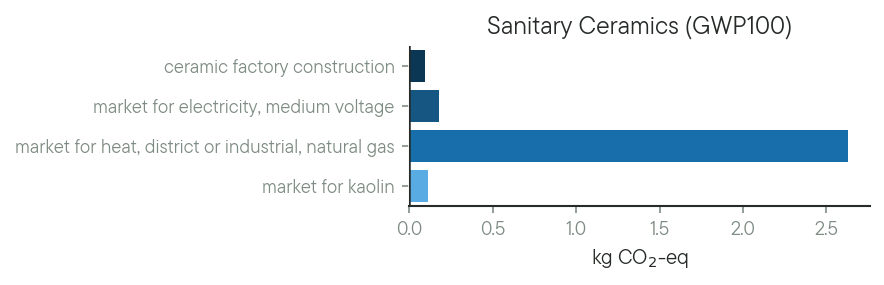

(<Figure size 900x300 with 1 Axes>,
 <Axes: title={'center': 'Sanitary Ceramics (GWP100)'}, xlabel='kg CO$_2$-eq'>)

In [19]:
# Example usage with a previously calculated contribution analysis dataframe:

plot_lca_bar(sanitary_ceramics_ca, title="Sanitary Ceramics (GWP100)", unit="kg CO$_2$-eq", figsize=(6, 2))

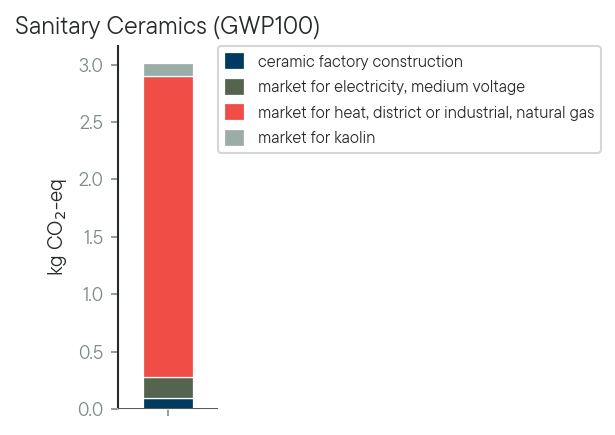

(<Figure size 600x450 with 1 Axes>,
 <Axes: title={'center': 'Sanitary Ceramics (GWP100)'}, ylabel='kg CO$_2$-eq'>)

In [31]:
plot_lca_stacked(sanitary_ceramics_ca, title="Sanitary Ceramics (GWP100)", unit="kg CO$_2$-eq", figsize=(4, 3))

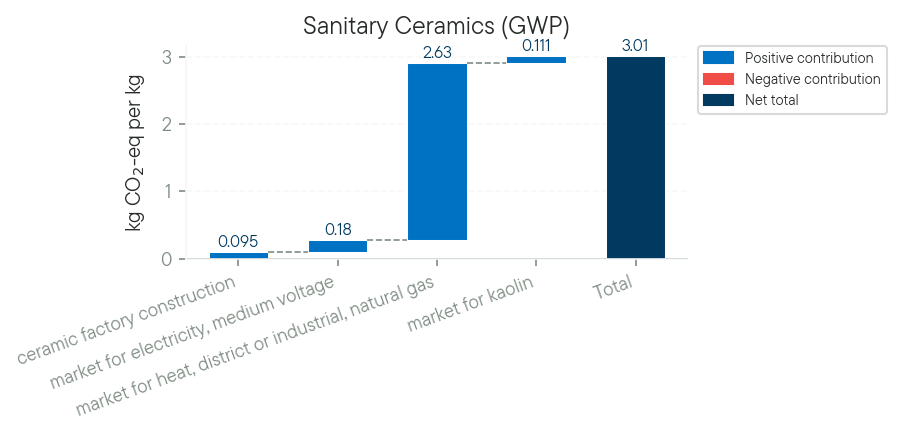

(<Figure size 900x450 with 1 Axes>,
 <Axes: title={'center': 'Sanitary Ceramics (GWP)'}, ylabel='kg CO$_2$-eq per kg'>)

In [23]:
plot_lca_waterfall(sanitary_ceramics_ca, title="Sanitary Ceramics (GWP)", unit="kg CO$_2$-eq per kg", figsize=(6, 3))

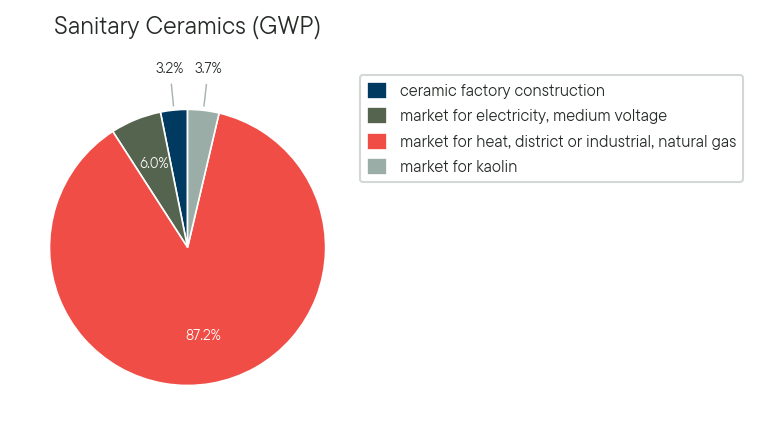

(<Figure size 900x450 with 1 Axes>,
 <Axes: title={'center': 'Sanitary Ceramics (GWP)'}>)

In [29]:
plot_lca_pie(sanitary_ceramics_ca, title="Sanitary Ceramics (GWP)", figsize=(6, 3))

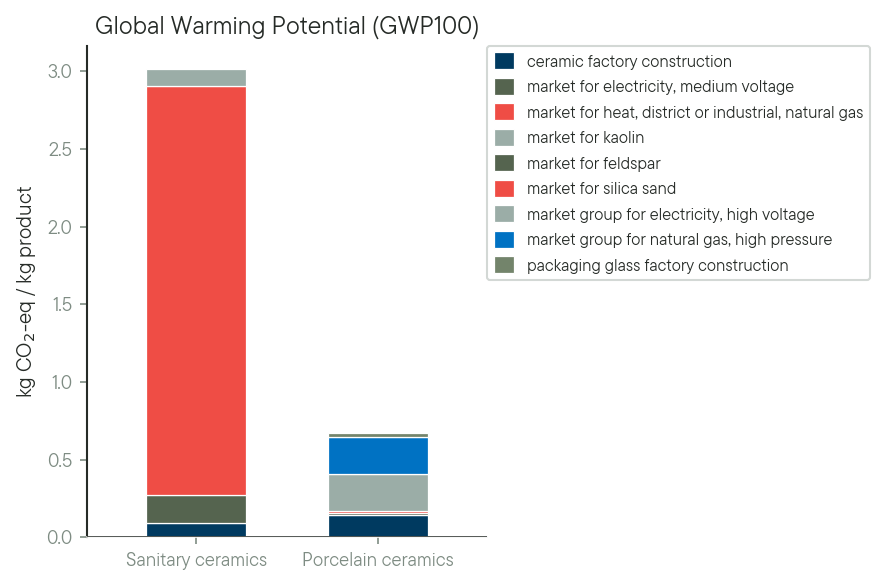

(<Figure size 900x600 with 1 Axes>,
 <Axes: title={'center': 'Global Warming Potential (GWP100)'}, ylabel='kg CO$_2$-eq / kg product'>)

In [40]:
plot_lca_stacked(
    sanitary_ceramics_ca,
    porcelain_ceramics_ca,
    labels=["Sanitary ceramics", "Porcelain ceramics"],
    title="Global Warming Potential (GWP100)",
    unit="kg CO$_2$-eq / kg product",
    figsize=(6, 4),
)

In [22]:
# Next step: add a second bar to the right of this to allow direct comparison of two products or scenarios.